In [1]:
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

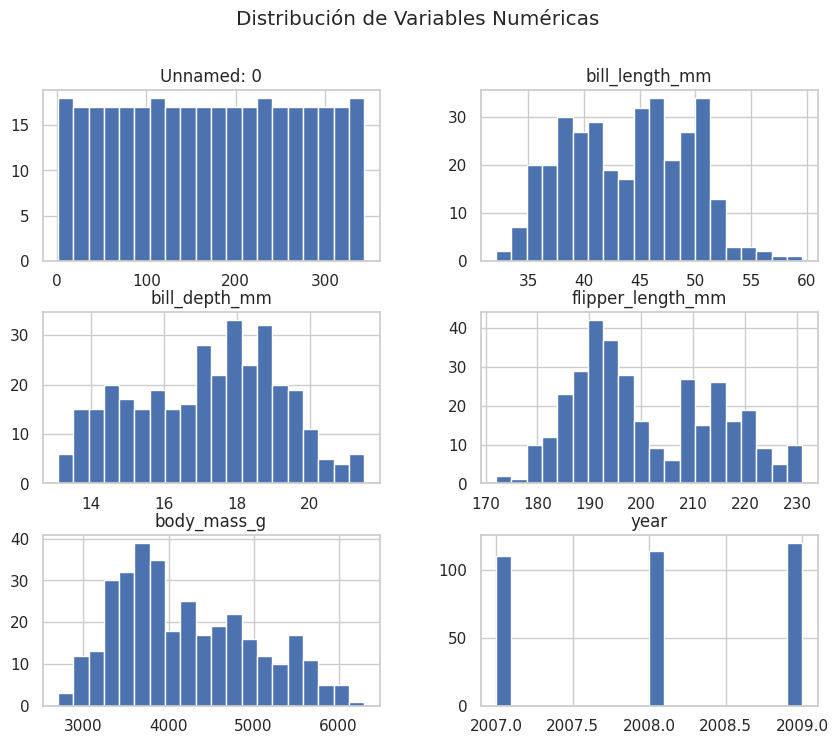

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(bins=20, figsize=(10,8))
plt.suptitle("Distribución de Variables Numéricas")
plt.show()

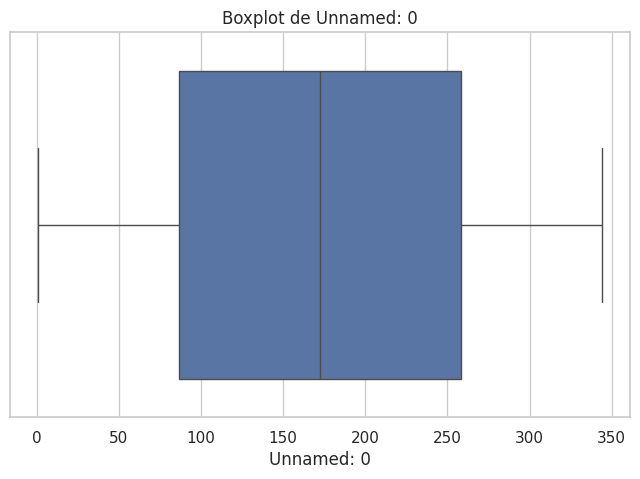

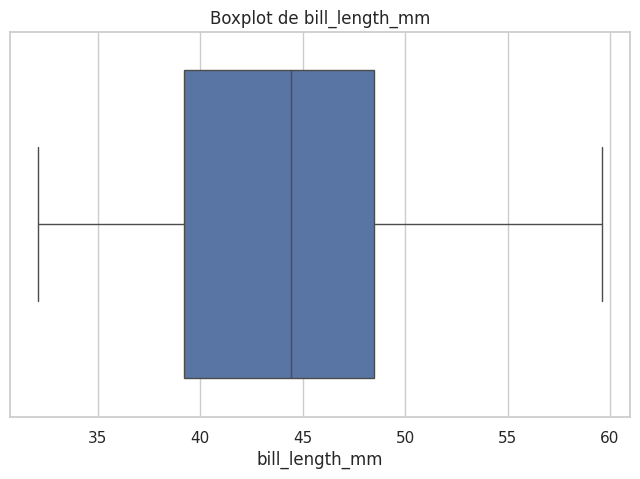

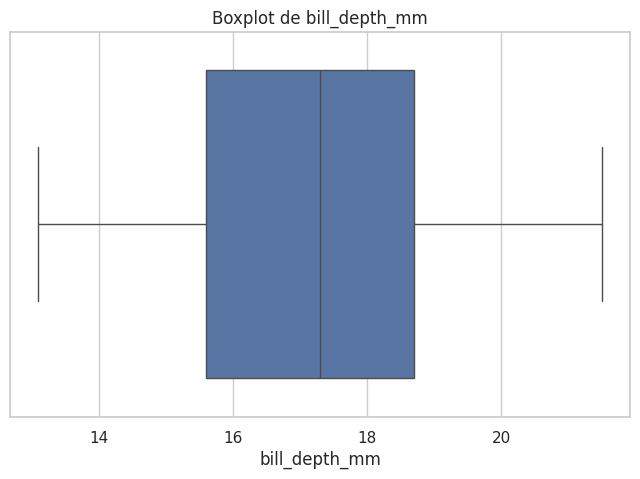

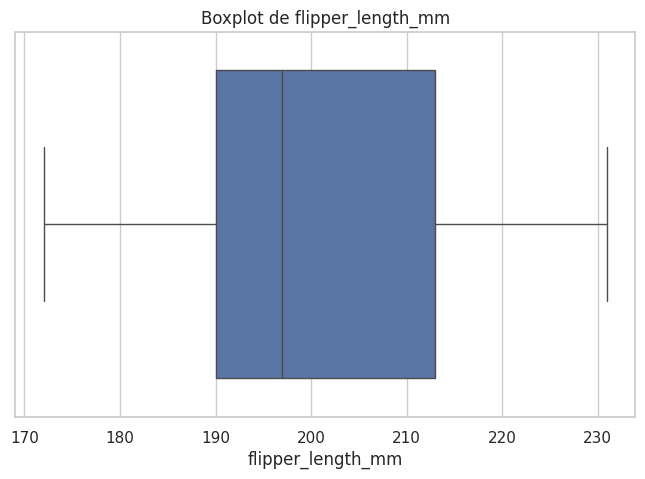

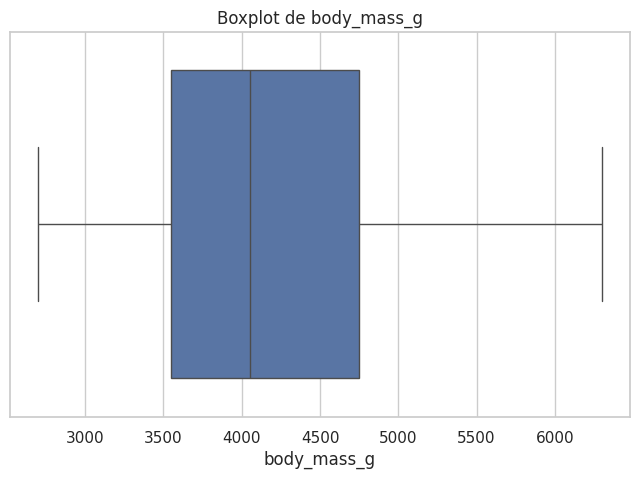

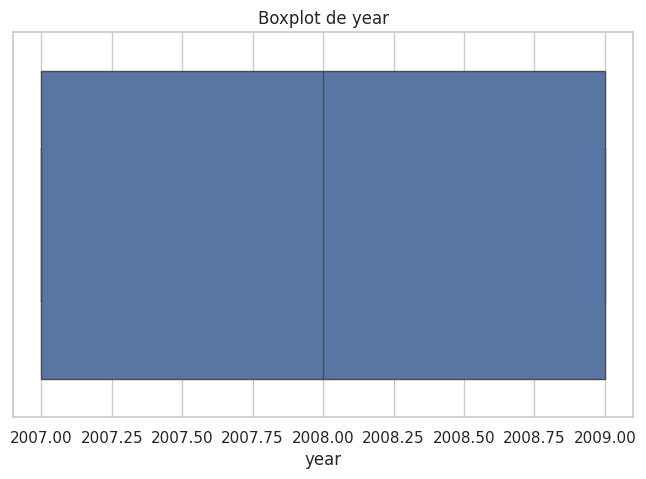

In [7]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

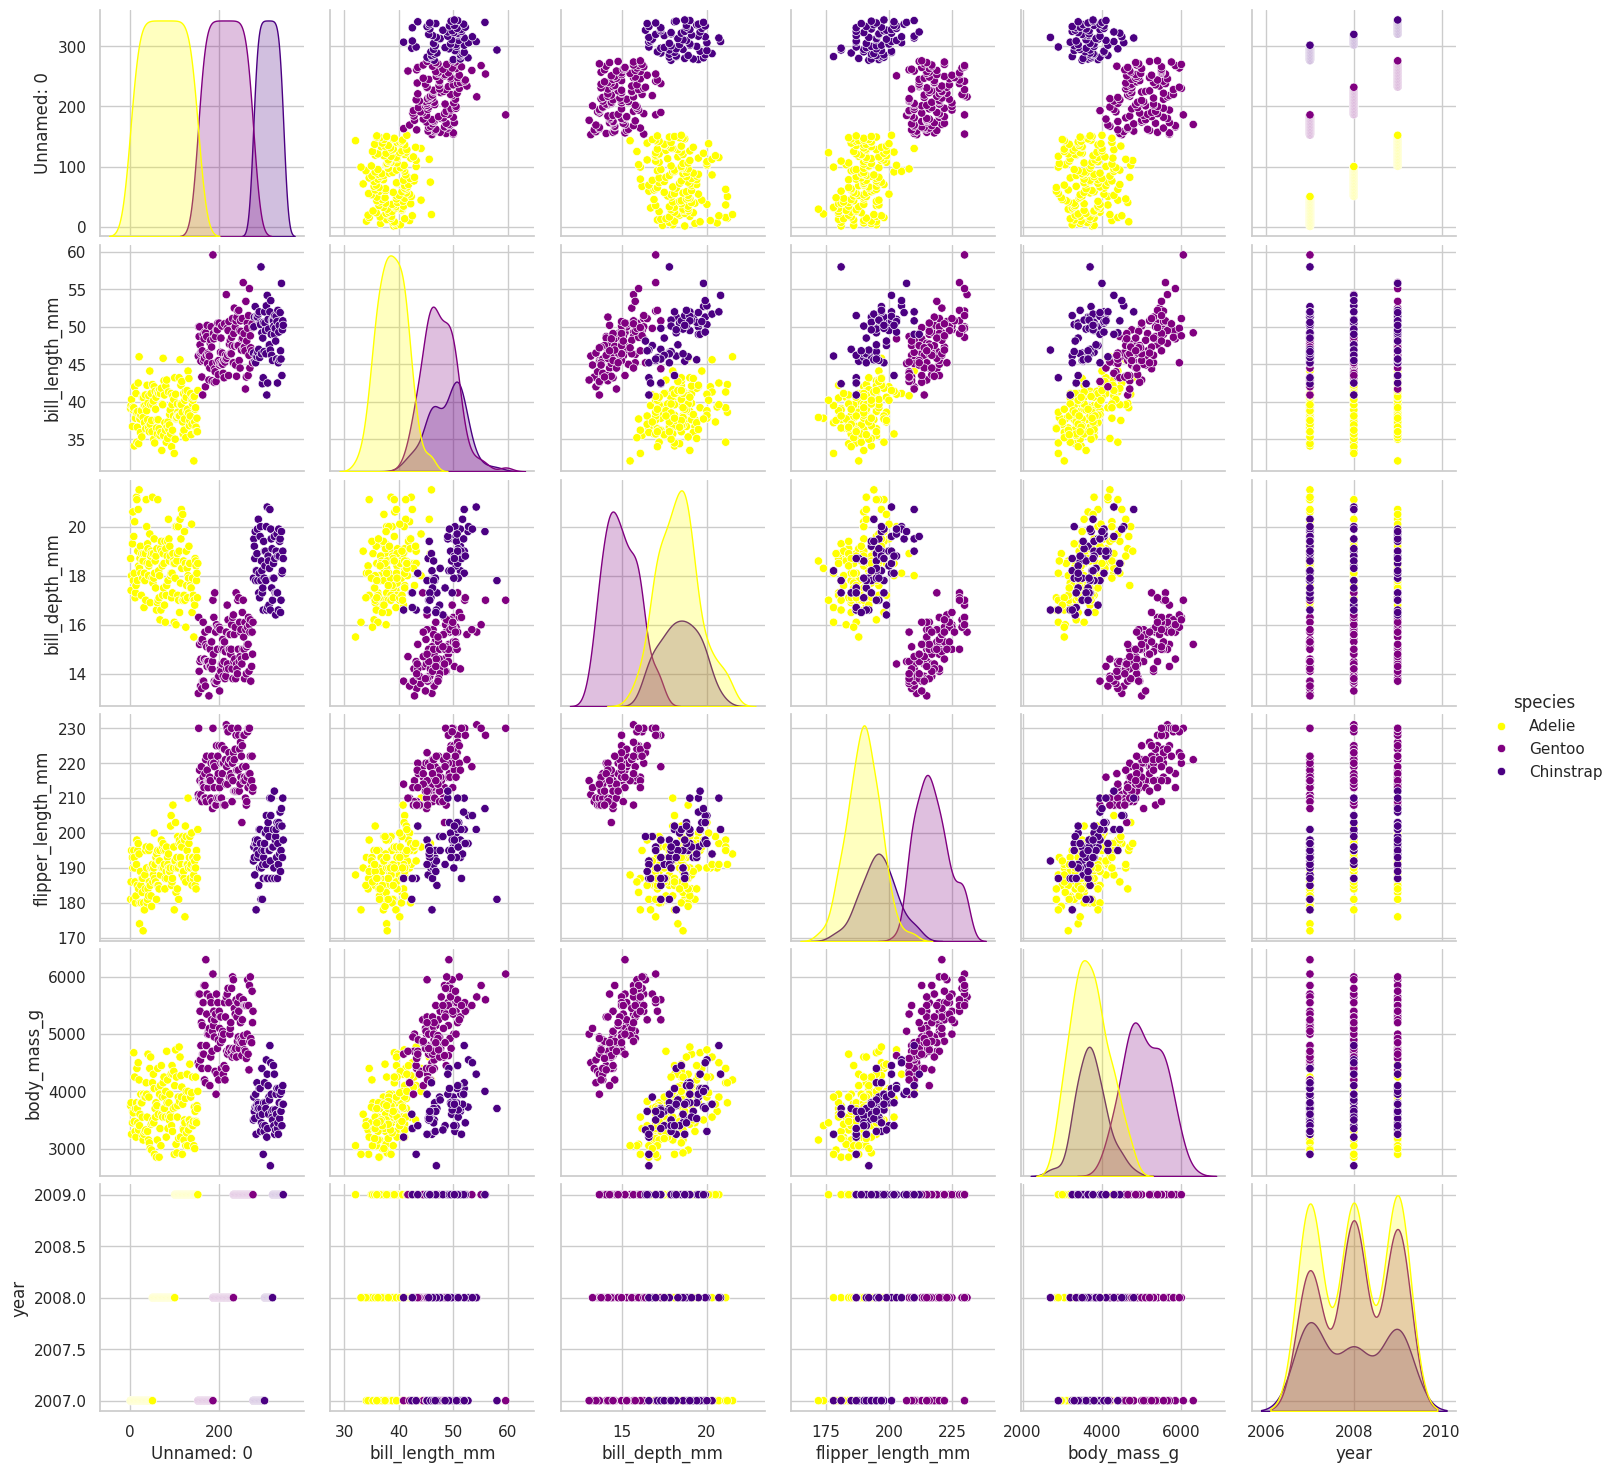

In [42]:
sns.pairplot(
    df,
    hue="species",
    palette=["yellow", "purple", "indigo"]
)

plt.show()

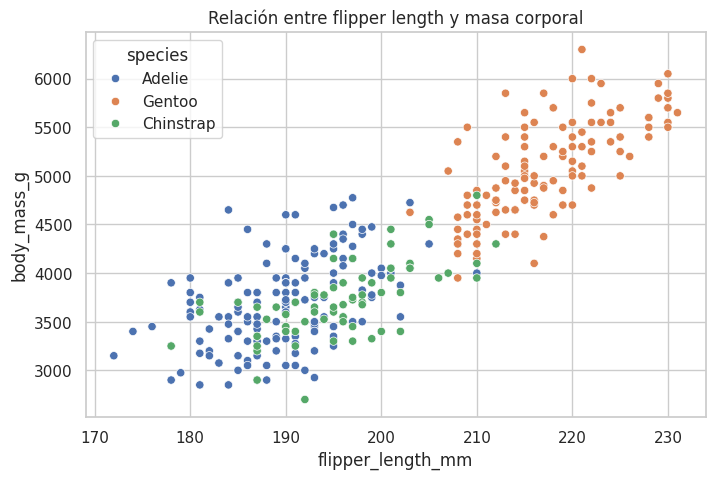

In [9]:
sns.scatterplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species"
)
plt.title("Relación entre flipper length y masa corporal")
plt.show()

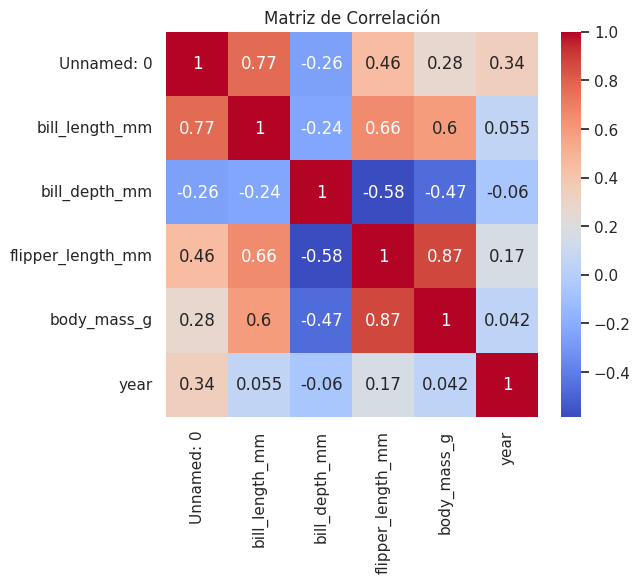

In [10]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

In [11]:


df_encoded = df.copy()

# Label Encoding para variables categóricas
le = LabelEncoder()

df_encoded["species"] = le.fit_transform(df_encoded["species"])
df_encoded["island"] = le.fit_transform(df_encoded["island"])
df_encoded["sex"] = le.fit_transform(df_encoded["sex"])

df_encoded.head()

,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,0,2,39.1,18.7,181.0,3750.0,1,2007
1,2,0,2,39.5,17.4,186.0,3800.0,0,2007
2,3,0,2,40.3,18.0,195.0,3250.0,0,2007
3,4,0,2,NaN,NaN,NaN,NaN,2,2007
4,5,0,2,36.7,19.3,193.0,3450.0,0,2007


In [12]:


X = df_encoded.drop("body_mass_g", axis=1)
y = df_encoded["body_mass_g"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (275, 8)
Test: (69, 8)


regresion lineal

In [28]:
# ===============================
# 7. Regresión Lineal
# ===============================

# Eliminamos columnas que no sirven
df_model = df.copy()
df_model = df_model.drop(columns=["Unnamed: 0"])

# Eliminar valores faltantes
df_model = df_model.dropna()

# Encoding de variables categóricas
df_model = pd.get_dummies(df_model, columns=["species","island","sex"], drop_first=True)

# Variables predictoras y objetivo
X = df_model.drop("body_mass_g", axis=1)
y = df_model["body_mass_g"]

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [29]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [30]:
y_pred = lr_model.predict(X_test)

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R2: 0.8733796882760965
MAE: 204.01786326177904
MSE: 75702.45953804899
RMSE: 275.1407994791921


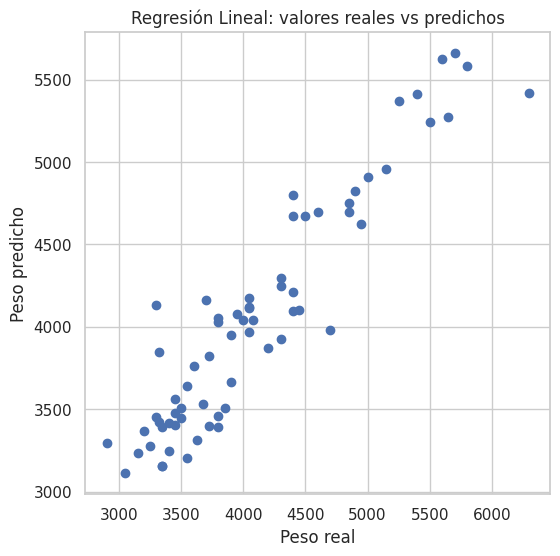

In [32]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Peso real")
plt.ylabel("Peso predicho")

plt.title("Regresión Lineal: valores reales vs predichos")

plt.show()

REGRESION LOGISTICA



In [33]:


df_log = df.copy()

df_log = df_log.drop(columns=["Unnamed: 0"])
df_log = df_log.dropna()

# Variable objetivo
y = df_log["species"]

# Variables predictoras
X = df_log.drop("species", axis=1)

# Encoding de variables categóricas
X = pd.get_dummies(X, columns=["island","sex"], drop_first=True)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [36]:
y_pred = log_model.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


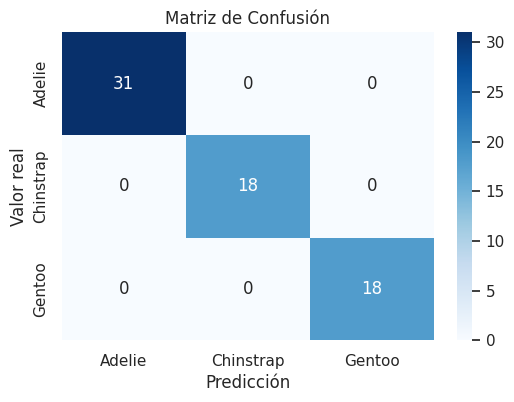

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=log_model.classes_,
    yticklabels=log_model.classes_
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.title("Matriz de Confusión")

plt.show()